# Exploratory Data Analysis: KuaiRand-Pure

This notebook explores the KuaiRand-Pure dataset to inform the design of a video recommendation system for Kuaishou. The dataset uniquely contains both **algorithmically curated** and **randomly exposed** interaction logs, letting us quantify recommendation bias directly.

**Modeling direction:** SVD-based collaborative filtering with a user-feature clustering baseline for comparison. The EDA is structured to answer the key design decisions:
1. What engagement metric should we predict?
2. Does a temporal leave-one-out split work with this data?
3. How does the interaction matrix look for SVD, and can user features provide a useful baseline?

## Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = 'KuaiRand-Pure/data'

## Data Loading

The dataset consists of six CSV files across three categories:
- **Interaction logs:** Random exposures (Apr 22 – May 8), standard exposures in two time windows
- **User features:** Demographics and activity metrics for ~27K users
- **Video features:** Basic metadata and monthly aggregate statistics for ~7.6K videos

In [2]:
log_rand = pd.read_csv(f'{DATA_DIR}/log_random_4_22_to_5_08_pure.csv')
log_std1 = pd.read_csv(f'{DATA_DIR}/log_standard_4_08_to_4_21_pure.csv')
log_std2 = pd.read_csv(f'{DATA_DIR}/log_standard_4_22_to_5_08_pure.csv')

user_feat = pd.read_csv(f'{DATA_DIR}/user_features_pure.csv')
video_basic = pd.read_csv(f'{DATA_DIR}/video_features_basic_pure.csv')
video_stats = pd.read_csv(f'{DATA_DIR}/video_features_statistic_pure.csv')

In [3]:
log_rand['source'] = 'random'
log_std1['source'] = 'standard_period1'
log_std2['source'] = 'standard_period2'

logs = pd.concat([log_rand, log_std1, log_std2], ignore_index=True)

print(f"Combined logs: {logs.shape[0]:,} rows x {logs.shape[1]} columns")
print(f"  Random exposures:    {log_rand.shape[0]:,}")
print(f"  Standard (period 1): {log_std1.shape[0]:,}")
print(f"  Standard (period 2): {log_std2.shape[0]:,}")
print(f"\nUsers:  {user_feat.shape[0]:,} rows x {user_feat.shape[1]} columns")
print(f"Videos (basic): {video_basic.shape[0]:,} rows x {video_basic.shape[1]} columns")
print(f"Videos (stats): {video_stats.shape[0]:,} rows x {video_stats.shape[1]} columns")

Combined logs: 2,622,668 rows x 20 columns
  Random exposures:    1,186,059
  Standard (period 1): 1,141,112
  Standard (period 2): 295,497

Users:  27,285 rows x 31 columns
Videos (basic): 7,583 rows x 12 columns
Videos (stats): 7,583 rows x 52 columns


---
## Phase 1: Data Integrity and Quality Checks

Before any analysis, we validate that the data is clean enough to trust.

### 1.1 Missingness

In [4]:
def summarize_missing(df, name):
    """Report columns with any missing values."""
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"{name}: No missing values")
    else:
        pct = (missing / len(df) * 100).round(2)
        report = pd.DataFrame({'missing': missing, 'pct': pct})
        print(f"\n{name} — columns with missing values:")
        print(report.to_string())

for df, name in [(logs, 'Interaction Logs'), (user_feat, 'User Features'),
                  (video_basic, 'Video Basic'), (video_stats, 'Video Stats')]:
    summarize_missing(df, name)

Interaction Logs: No missing values

User Features — columns with missing values:
               missing   pct
onehot_feat4       874  3.20
onehot_feat12      714  2.62
onehot_feat13      714  2.62
onehot_feat14      714  2.62
onehot_feat15      714  2.62
onehot_feat16      714  2.62
onehot_feat17      714  2.62

Video Basic — columns with missing values:
                missing   pct
video_duration      239  3.15
music_type          203  2.68
tag                  96  1.27
Video Stats: No missing values


### 1.2 User-Item Interaction Matrix Sparsity

In [5]:
n_users = logs['user_id'].nunique()
n_videos = logs['video_id'].nunique()
n_interactions = logs.shape[0]
n_unique_pairs = logs.groupby(['user_id', 'video_id']).ngroups
sparsity = 1 - n_unique_pairs / (n_users * n_videos)

print(f"Unique users:  {n_users:,}")
print(f"Unique videos: {n_videos:,}")
print(f"Total interactions: {n_interactions:,}")
print(f"Unique user-video pairs: {n_unique_pairs:,}")
print(f"Interaction matrix sparsity: {sparsity:.6f} ({sparsity*100:.4f}%)")

Unique users:  27,285
Unique videos: 7,583
Total interactions: 2,622,668
Unique user-video pairs: 2,560,247
Interaction matrix sparsity: 0.987626 (98.7626%)


### 1.3 Play Time vs. Duration Consistency

We check for anomalies where `play_time_ms` is negative or unreasonably exceeds `duration_ms` (beyond what looping would explain).

In [6]:
valid_dur = logs[logs['duration_ms'] > 0].copy()
valid_dur['play_ratio'] = valid_dur['play_time_ms'] / valid_dur['duration_ms']

negative_play = (logs['play_time_ms'] < 0).sum()
zero_duration = (logs['duration_ms'] <= 0).sum()
extreme_ratio = (valid_dur['play_ratio'] > 5).sum()

print(f"Negative play_time_ms: {negative_play:,}")
print(f"Zero/negative duration_ms: {zero_duration:,}")
print(f"Play ratio > 5x duration: {extreme_ratio:,} ({extreme_ratio/len(valid_dur)*100:.2f}%)")

print(f"\nPlay ratio distribution (valid duration rows):")
print(valid_dur['play_ratio'].describe().to_string())

Negative play_time_ms: 0
Zero/negative duration_ms: 65,794
Play ratio > 5x duration: 1,939 (0.08%)

Play ratio distribution (valid duration rows):
count    2.556874e+06
mean     2.652860e-01
std      5.226958e-01
min      0.000000e+00
25%      1.454556e-02
50%      5.546706e-02
75%      2.817863e-01
max      1.031293e+02


### 1.4 Duplicate Log Entries

In [7]:
dup_count = logs.duplicated(subset=['user_id', 'video_id', 'time_ms']).sum()
print(f"Exact duplicate (user, video, timestamp) entries: {dup_count:,}")

Exact duplicate (user, video, timestamp) entries: 23,483


---
## Phase 2: Univariate Analysis

Understanding the marginal distributions of key variables before looking at relationships.

### 2.1 User Activity Distribution

Short-video platforms typically exhibit heavy-tailed user activity. This distribution directly affects SVD — users with very few interactions produce unreliable latent factors.

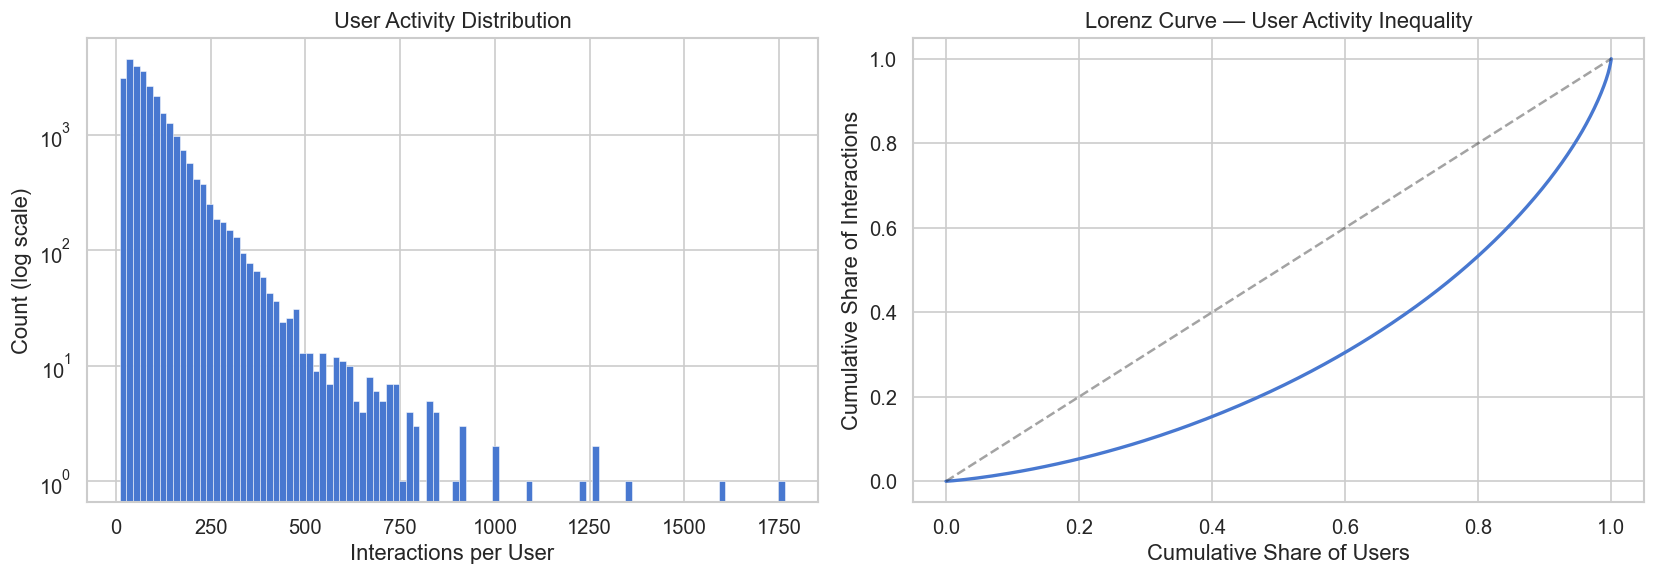

Top 10% of users account for 30.0% of all interactions
Median interactions per user: 73
Mean interactions per user: 96.1


In [8]:
user_activity = logs.groupby('user_id').size().rename('n_interactions')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_activity, bins=100, edgecolor='white', linewidth=0.3)
axes[0].set_yscale('log')
axes[0].set_xlabel('Interactions per User')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('User Activity Distribution')

sorted_activity = np.sort(user_activity.values)
cum_share = np.cumsum(sorted_activity) / sorted_activity.sum()
user_pct = np.arange(1, len(cum_share) + 1) / len(cum_share)
axes[1].plot(user_pct, cum_share, linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('Cumulative Share of Users')
axes[1].set_ylabel('Cumulative Share of Interactions')
axes[1].set_title('Lorenz Curve — User Activity Inequality')

plt.tight_layout()
plt.show()

top10_pct = sorted_activity[int(0.9 * len(sorted_activity)):].sum() / sorted_activity.sum()
print(f"Top 10% of users account for {top10_pct:.1%} of all interactions")
print(f"Median interactions per user: {int(np.median(sorted_activity))}")
print(f"Mean interactions per user: {sorted_activity.mean():.1f}")

### 2.2 Item Popularity Distribution

How concentrated are exposures and engagements across videos? This determines whether collaborative filtering has enough signal or if cold-start dominates.

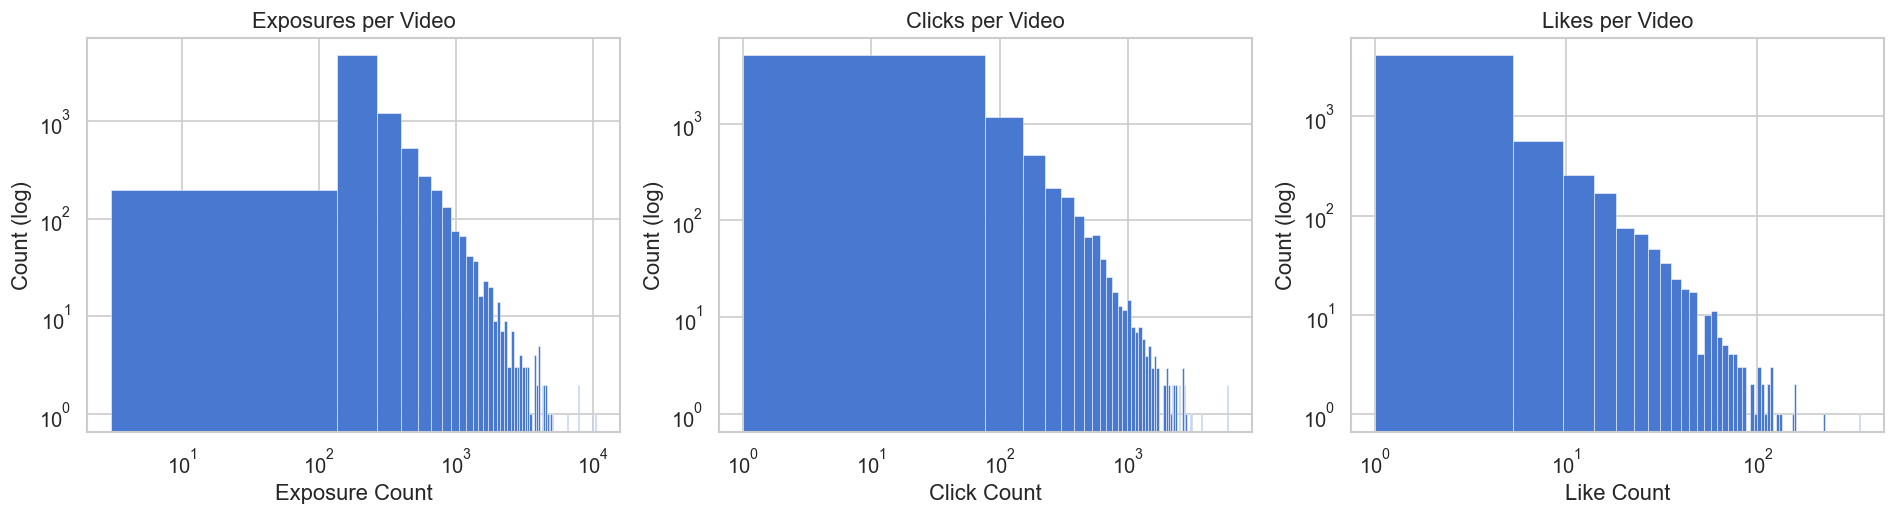

Videos with zero clicks: 4 / 7,583
Videos with zero likes:  2,115 / 7,583


In [9]:
item_pop = logs.groupby('video_id').agg(
    exposure_count=('video_id', 'size'),
    click_count=('is_click', 'sum'),
    like_count=('is_like', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, title in zip(axes,
    ['exposure_count', 'click_count', 'like_count'],
    ['Exposures per Video', 'Clicks per Video', 'Likes per Video']):
    vals = item_pop[col]
    ax.hist(vals[vals > 0], bins=80, edgecolor='white', linewidth=0.3)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Count (log)')
    ax.set_title(title)

plt.tight_layout()
plt.show()

print(f"Videos with zero clicks: {(item_pop['click_count'] == 0).sum():,} / {len(item_pop):,}")
print(f"Videos with zero likes:  {(item_pop['like_count'] == 0).sum():,} / {len(item_pop):,}")

### 2.3 Video Duration Distribution

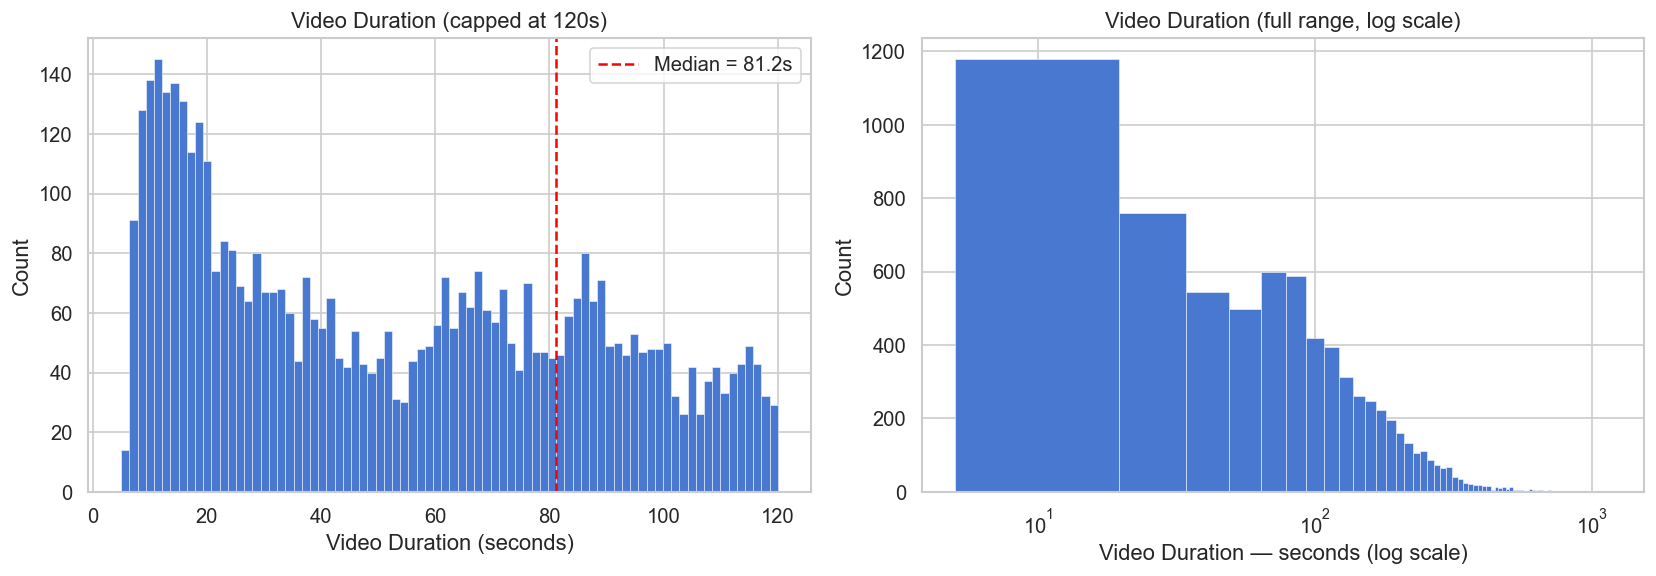

Duration stats (seconds): min=5.0, median=81.2, mean=108.6, max=1177.7


In [10]:
dur_sec = video_basic['video_duration'].dropna() / 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dur_sec[dur_sec <= 120], bins=80, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Video Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Video Duration (capped at 120s)')
axes[0].axvline(dur_sec.median(), color='red', linestyle='--', label=f'Median = {dur_sec.median():.1f}s')
axes[0].legend()

axes[1].hist(dur_sec, bins=80, edgecolor='white', linewidth=0.3)
axes[1].set_xscale('log')
axes[1].set_xlabel('Video Duration — seconds (log scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Video Duration (full range, log scale)')

plt.tight_layout()
plt.show()

print(f"Duration stats (seconds): min={dur_sec.min():.1f}, median={dur_sec.median():.1f}, "
      f"mean={dur_sec.mean():.1f}, max={dur_sec.max():.1f}")

### 2.4 Video Content Features

Tags and upload types are the main content-level signals available. With only 46 unique tags (24% of videos multi-labeled), these are tractable as side features for a hybrid model. Upload type encodes how the video was created, which may proxy for production quality.

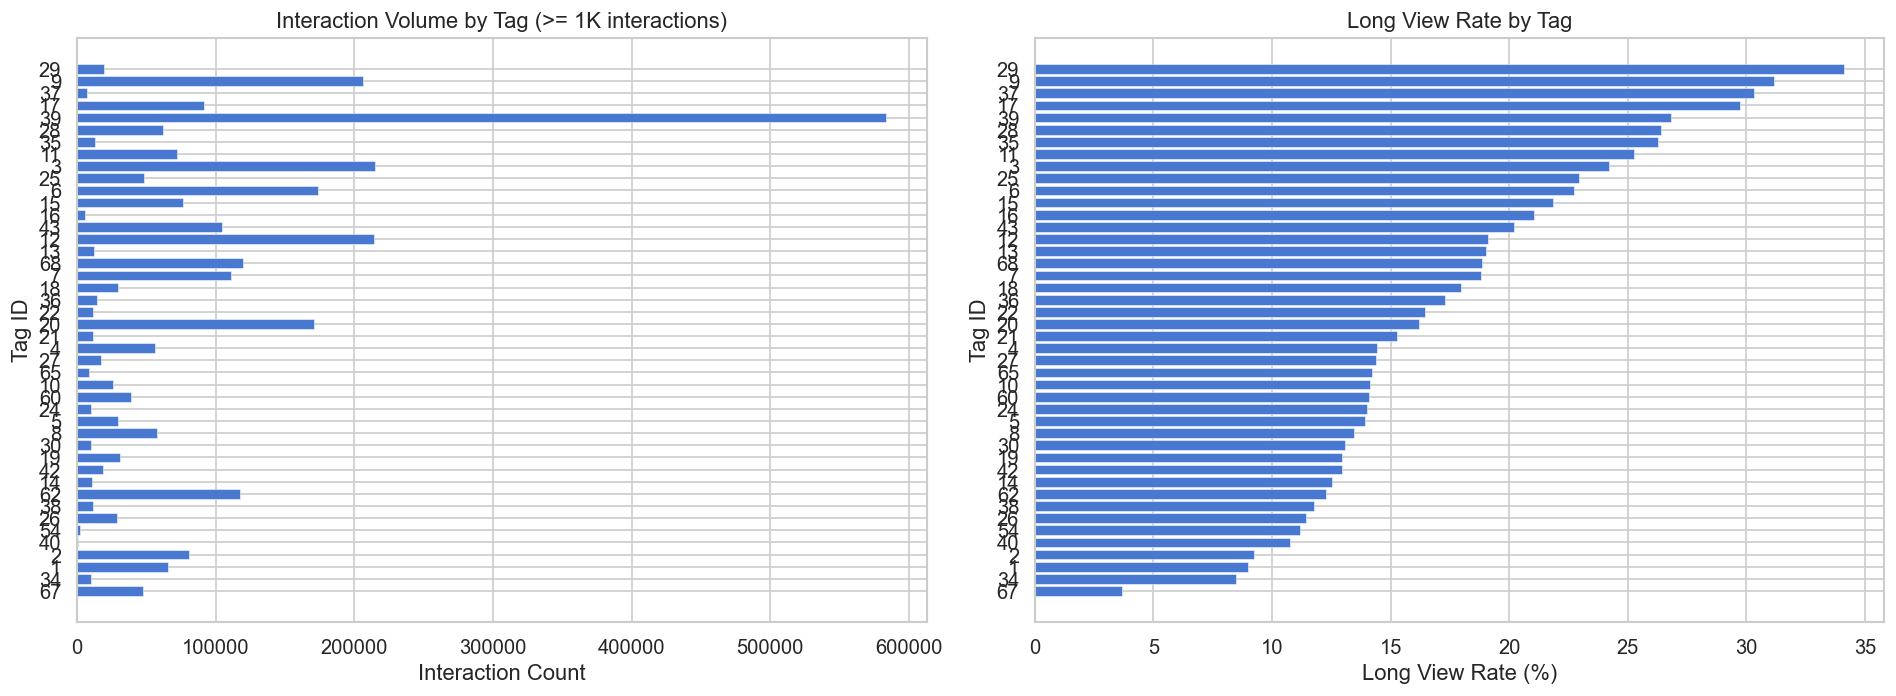

Long view rate across tags: min=3.7%, max=34.1%, range=30.4pp
Tags with >= 1K interactions: 44


In [11]:
# Merge video metadata with interaction logs to analyze engagement by content attributes
logs_with_video = logs.merge(
    video_basic[['video_id', 'tag', 'upload_type']],
    on='video_id', how='left'
)

# Explode comma-separated tags into one row per tag per interaction
logs_with_video['tag_list'] = logs_with_video['tag'].fillna('').str.split(',')
logs_tag = logs_with_video.explode('tag_list')
logs_tag = logs_tag[logs_tag['tag_list'].str.strip() != '']
logs_tag['tag_list'] = logs_tag['tag_list'].str.strip()

# Per-tag engagement rates — only use signals available before Phase 3
tag_eng = logs_tag.groupby('tag_list').agg(
    n_interactions=('video_id', 'size'),
    n_videos=('video_id', 'nunique'),
    click_rate=('is_click', 'mean'),
    long_view_rate=('long_view', 'mean'),
    like_rate=('is_like', 'mean'),
)

# Focus on tags with enough volume to be meaningful
tag_eng = tag_eng[tag_eng['n_interactions'] >= 1000].sort_values('long_view_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(tag_eng.index, tag_eng['n_interactions'], edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Interaction Count')
axes[0].set_ylabel('Tag ID')
axes[0].set_title('Interaction Volume by Tag (>= 1K interactions)')
axes[0].invert_yaxis()

# Long view rate as the engagement metric — more meaningful than click
axes[1].barh(tag_eng.index, tag_eng['long_view_rate'] * 100, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Long View Rate (%)')
axes[1].set_ylabel('Tag ID')
axes[1].set_title('Long View Rate by Tag')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

spread = tag_eng['long_view_rate'] * 100
print(f"Long view rate across tags: min={spread.min():.1f}%, max={spread.max():.1f}%, range={spread.max()-spread.min():.1f}pp")
print(f"Tags with >= 1K interactions: {len(tag_eng)}")

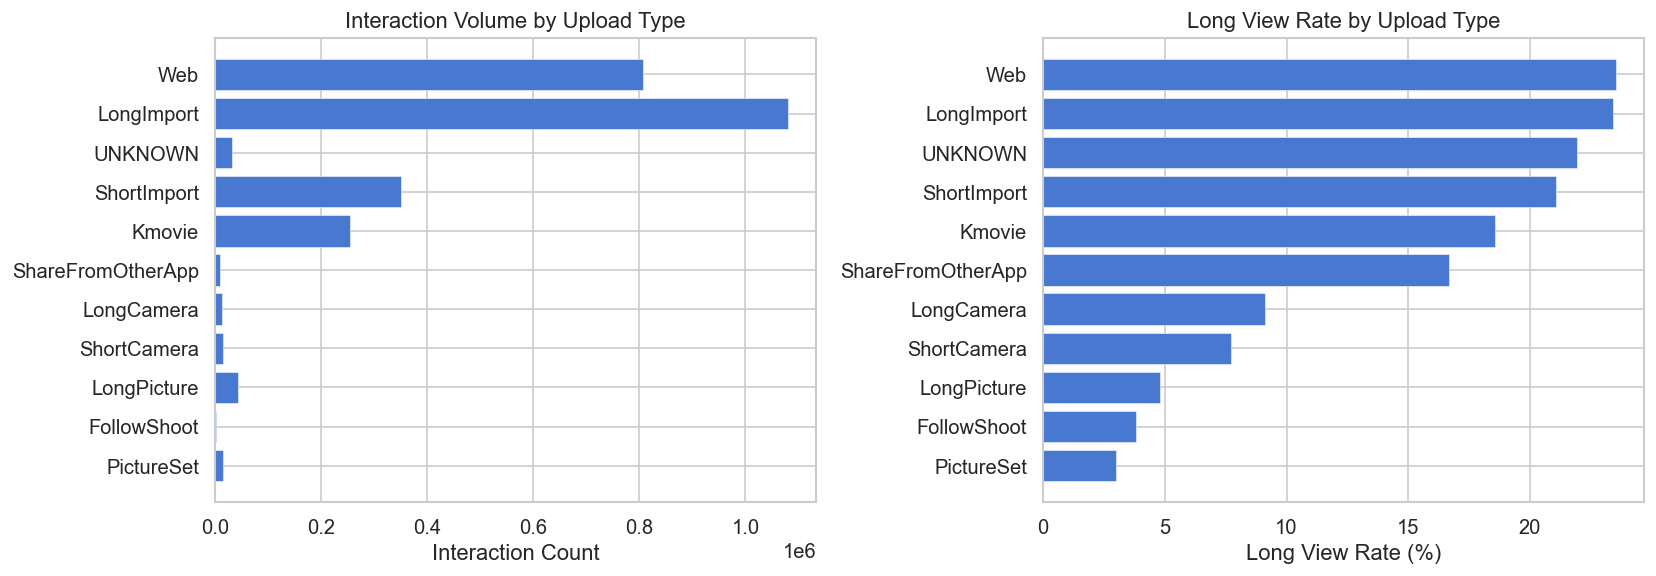

Long view rate by upload type: min=3.0%, max=23.5%

Upload type engagement detail:
                   n_interactions  n_videos  click_rate  long_view_rate  like_rate
upload_type                                                                       
Web                        807323      2416       34.90           23.53       1.06
LongImport                1079630      2925       34.94           23.43       1.20
UNKNOWN                     31407        80       31.94           21.94       1.17
ShortImport                350395       917       31.10           21.06       1.86
Kmovie                     255101       879       29.45           18.55       0.89
ShareFromOtherApp            9058        29       26.98           16.69       0.77
LongCamera                  14130        64       17.72            9.13       0.62
ShortCamera                 14432        43       19.02            7.74       1.02
LongPicture                 43156       143       15.53            4.79       2.42
Foll

In [12]:
# Upload type reflects how the video was produced — may proxy for content quality
upload_eng = logs_with_video.groupby('upload_type').agg(
    n_interactions=('video_id', 'size'),
    n_videos=('video_id', 'nunique'),
    click_rate=('is_click', 'mean'),
    long_view_rate=('long_view', 'mean'),
    like_rate=('is_like', 'mean'),
)
# Only show types with meaningful volume
upload_eng = upload_eng[upload_eng['n_interactions'] >= 500].sort_values('long_view_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(upload_eng.index, upload_eng['n_interactions'], edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Interaction Count')
axes[0].set_title('Interaction Volume by Upload Type')
axes[0].invert_yaxis()

axes[1].barh(upload_eng.index, upload_eng['long_view_rate'] * 100, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Long View Rate (%)')
axes[1].set_title('Long View Rate by Upload Type')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

spread_up = upload_eng['long_view_rate'] * 100
print(f"Long view rate by upload type: min={spread_up.min():.1f}%, max={spread_up.max():.1f}%")
print(f"\nUpload type engagement detail:")
display_up = upload_eng.copy()
display_up[['click_rate', 'long_view_rate', 'like_rate']] = (display_up[['click_rate', 'long_view_rate', 'like_rate']] * 100).round(2)
print(display_up.to_string())

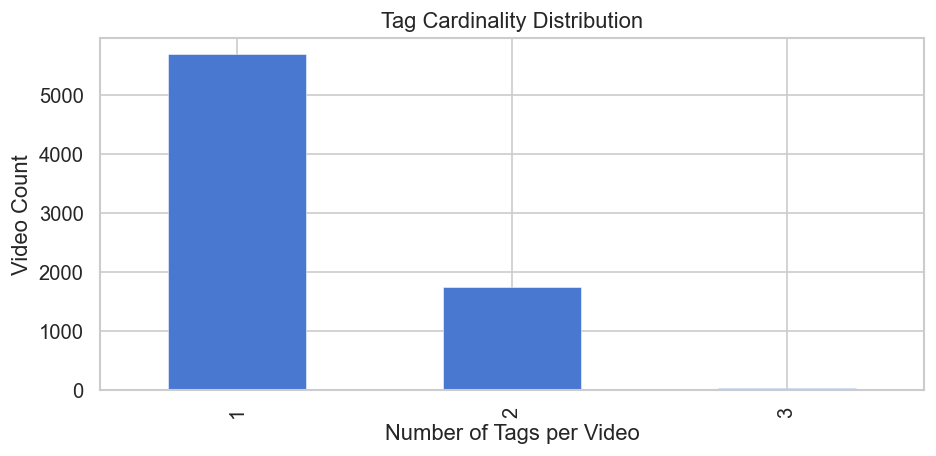

Videos with 1 tag: 5,696 (76.1%)
Videos with 2+ tags: 1,791 (23.9%)
Max tags on a single video: 3


In [13]:
# Tag structure: how many tags per video, and which tags co-occur
tags_per_video = video_basic['tag'].dropna().str.split(',').apply(len)

fig, ax = plt.subplots(figsize=(8, 4))
tags_per_video.value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Number of Tags per Video')
ax.set_ylabel('Video Count')
ax.set_title('Tag Cardinality Distribution')
plt.tight_layout()
plt.show()

print(f"Videos with 1 tag: {(tags_per_video == 1).sum():,} ({(tags_per_video == 1).mean()*100:.1f}%)")
print(f"Videos with 2+ tags: {(tags_per_video >= 2).sum():,} ({(tags_per_video >= 2).mean()*100:.1f}%)")
print(f"Max tags on a single video: {tags_per_video.max()}")

### 2.5 User Feature Distributions

These features will be used for the clustering baseline, so their distributions and separability matter.

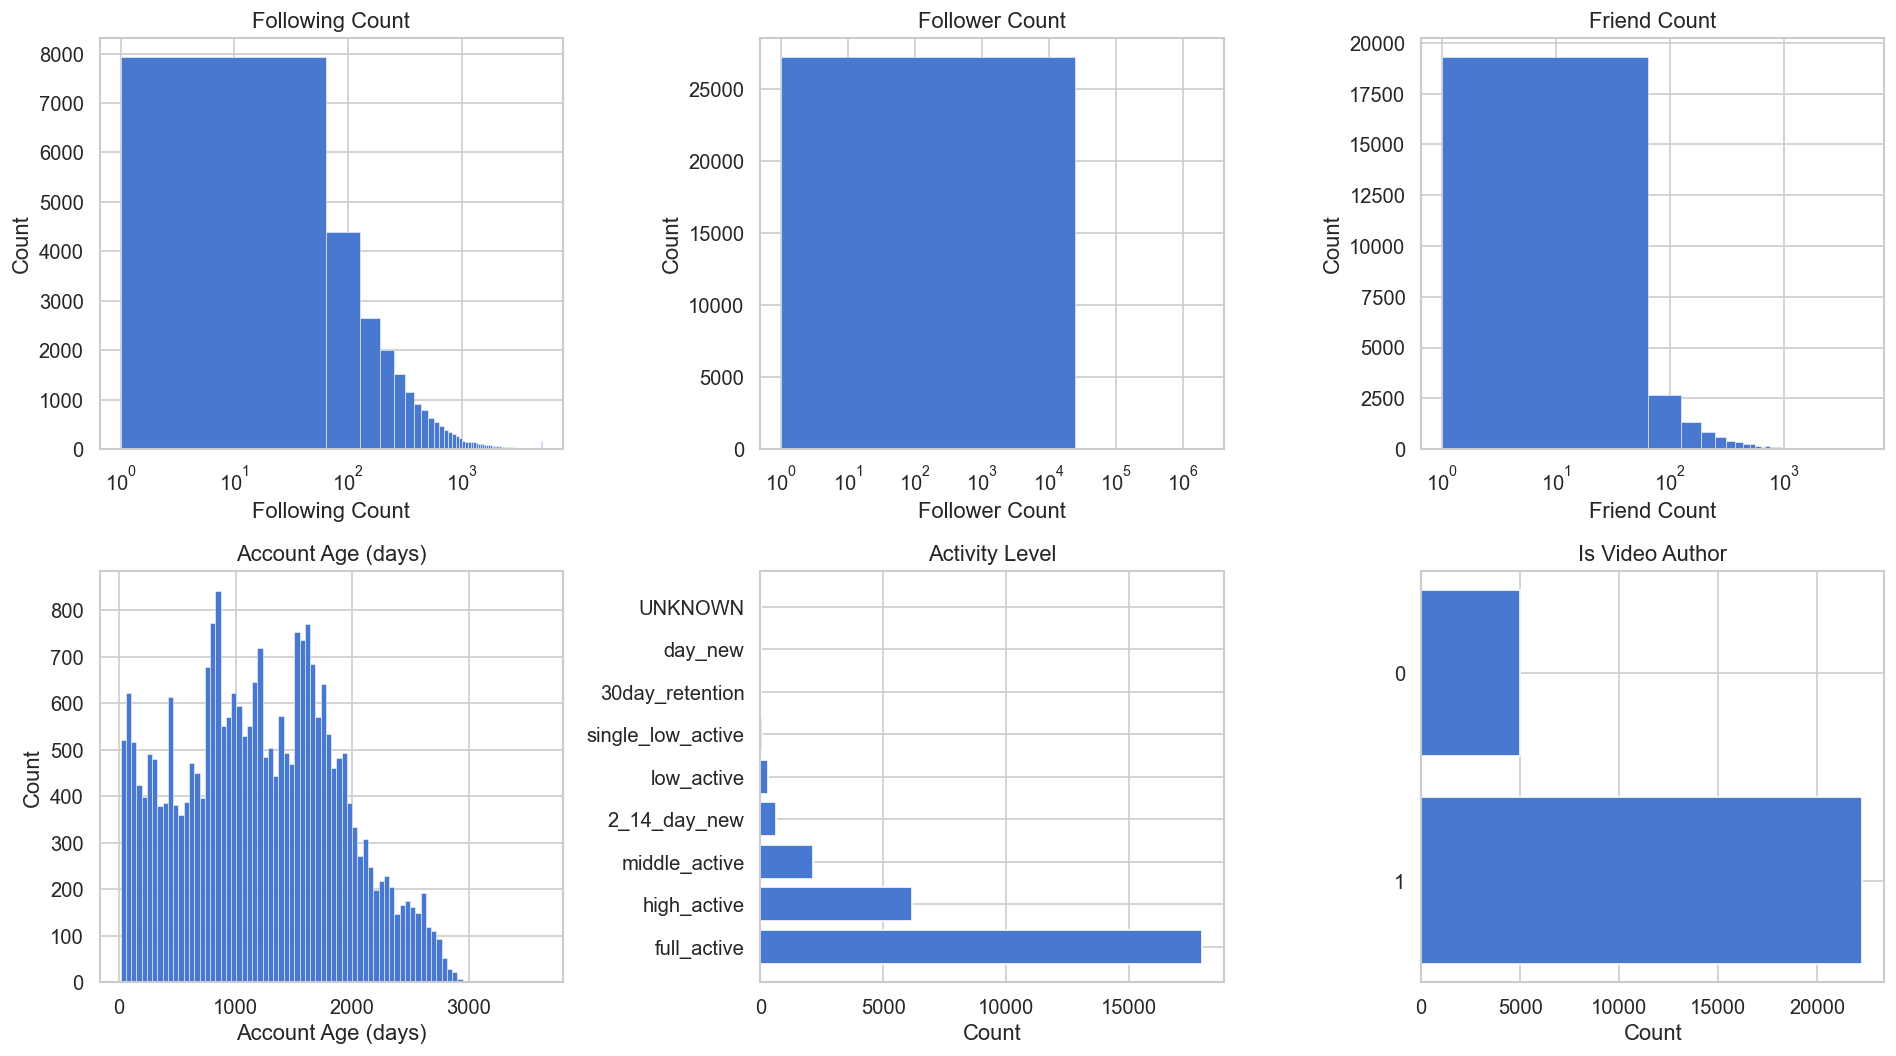

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

num_feats = [
    ('follow_user_num', 'Following Count', True),
    ('fans_user_num', 'Follower Count', True),
    ('friend_user_num', 'Friend Count', True),
    ('register_days', 'Account Age (days)', False),
]

for ax, (col, label, use_log) in zip(axes.flat, num_feats):
    vals = user_feat[col].dropna()
    if use_log:
        ax.hist(vals + 1, bins=80, edgecolor='white', linewidth=0.3)
        ax.set_xscale('log')
    else:
        ax.hist(vals, bins=80, edgecolor='white', linewidth=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)

cat_feats = [
    ('user_active_degree', 'Activity Level'),
    ('is_video_author', 'Is Video Author'),
]

for ax, (col, label) in zip(axes.flat[4:], cat_feats):
    counts = user_feat[col].value_counts()
    ax.barh(counts.index.astype(str), counts.values)
    ax.set_xlabel('Count')
    ax.set_title(label)

plt.tight_layout()
plt.show()

---
## Phase 3: Algorithmic Bias — Standard vs. Random

Random exposures (`is_rand == 1`) bypass the recommendation algorithm. Comparing engagement rates directly measures the algorithm's amplification effect, and tells us how biased training data from standard logs would be.

### 3.1 Engagement Rate Comparison

In [15]:
logs['valid_play'] = ((logs['play_time_ms'] >= 7000) | (logs['long_view'] == 1)).astype(int)
logs['complete_play'] = (
    (logs['duration_ms'] > 0) &
    (logs['play_time_ms'] >= logs['duration_ms'] * 0.9)
).astype(int)

engagement_cols = ['is_click', 'valid_play', 'complete_play', 'is_like', 'is_comment', 'is_follow', 'is_hate']

eng_by_rand = logs.groupby('is_rand')[engagement_cols].mean()
eng_by_rand.index = eng_by_rand.index.map({0: 'Standard', 1: 'Random'})

print("Engagement Rates by Exposure Type:")
print((eng_by_rand * 100).round(3).to_string())

Engagement Rates by Exposure Type:
          is_click  valid_play  complete_play  is_like  is_comment  is_follow  is_hate
is_rand                                                                               
Standard    45.965      44.341         19.083    1.848       0.255      0.107    0.049
Random      17.616      17.206          4.068    0.480       0.035      0.026    0.114


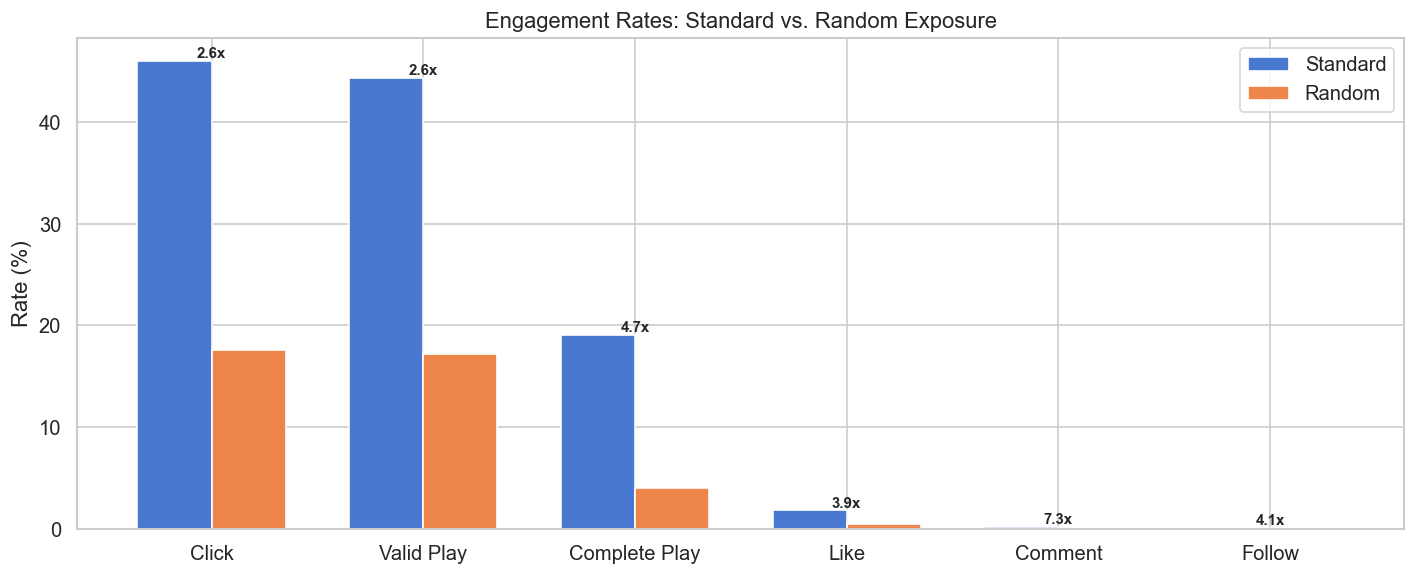

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

eng_plot = eng_by_rand[['is_click', 'valid_play', 'complete_play', 'is_like', 'is_comment', 'is_follow']].T
x = np.arange(len(eng_plot))
width = 0.35

ax.bar(x - width/2, eng_plot['Standard'] * 100, width, label='Standard')
ax.bar(x + width/2, eng_plot['Random'] * 100, width, label='Random')

ax.set_ylabel('Rate (%)')
ax.set_title('Engagement Rates: Standard vs. Random Exposure')
ax.set_xticks(x)
ax.set_xticklabels(['Click', 'Valid Play', 'Complete Play', 'Like', 'Comment', 'Follow'])
ax.legend()

for i, metric in enumerate(eng_plot.index):
    std_val = eng_plot.loc[metric, 'Standard']
    rand_val = eng_plot.loc[metric, 'Random']
    if rand_val > 0:
        ratio = std_val / rand_val
        ax.text(i, max(std_val, rand_val) * 100 + 0.3, f'{ratio:.1f}x',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.2 Engagement Funnel

The conversion funnel from exposure to deeper engagement actions, split by regime. This directly informs which engagement signal has enough volume to serve as a training target.

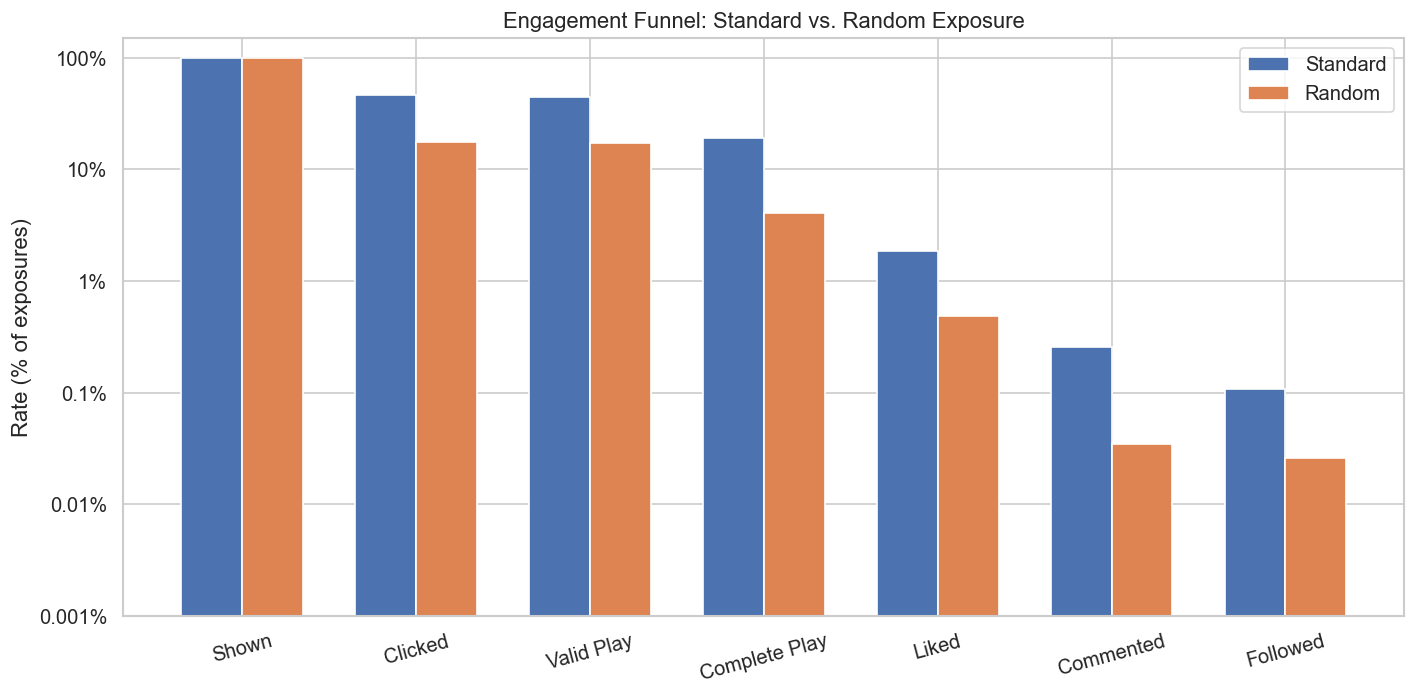


Funnel Rates (%):
               Standard   Random
Shown           100.000  100.000
Clicked          45.965   17.616
Valid Play       44.341   17.206
Complete Play    19.083    4.068
Liked             1.848    0.480
Commented         0.255    0.035
Followed          0.107    0.026


In [17]:
funnel_metrics = {
    'Shown': 'count',
    'Clicked': 'is_click',
    'Valid Play': 'valid_play',
    'Complete Play': 'complete_play',
    'Liked': 'is_like',
    'Commented': 'is_comment',
    'Followed': 'is_follow'
}

funnel_data = {}
for rand_flag, label in [(0, 'Standard'), (1, 'Random')]:
    subset = logs[logs['is_rand'] == rand_flag]
    total = len(subset)
    rates = [100.0]
    for metric_name, col in list(funnel_metrics.items())[1:]:
        rates.append(subset[col].sum() / total * 100)
    funnel_data[label] = rates

funnel_df = pd.DataFrame(funnel_data, index=list(funnel_metrics.keys()))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(funnel_df))
width = 0.35

ax.bar(x - width/2, funnel_df['Standard'], width, label='Standard', color='#4C72B0')
ax.bar(x + width/2, funnel_df['Random'], width, label='Random', color='#DD8452')

ax.set_ylabel('Rate (% of exposures)')
ax.set_title('Engagement Funnel: Standard vs. Random Exposure')
ax.set_xticks(x)
ax.set_xticklabels(funnel_df.index, rotation=15)
ax.legend()
ax.set_yscale('log')
ax.set_ylim(bottom=0.001)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.3g}%'))

plt.tight_layout()
plt.show()

print("\nFunnel Rates (%):")
print(funnel_df.round(3).to_string())

### 3.3 Engagement vs. Video Duration

Play progress (play_time / duration) varies with video length. The standard algorithm partially compensates — matching users to appropriate-length content — while random exposure shows the raw drop-off.

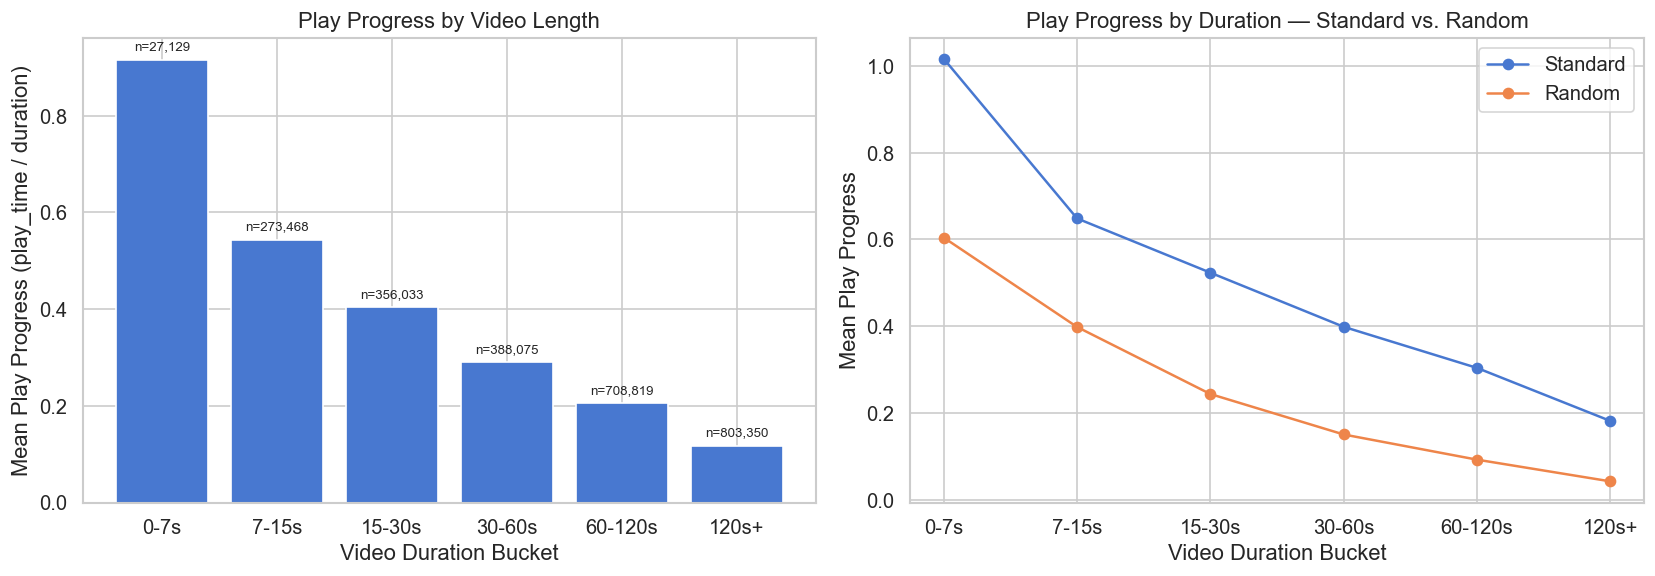

In [18]:
dur_analysis = logs[(logs['duration_ms'] > 0) & (logs['play_time_ms'] >= 0)].copy()
dur_analysis['duration_sec'] = dur_analysis['duration_ms'] / 1000
dur_analysis['play_progress'] = (dur_analysis['play_time_ms'] / dur_analysis['duration_ms']).clip(upper=5)

bins = [0, 7, 15, 30, 60, 120, float('inf')]
labels = ['0-7s', '7-15s', '15-30s', '30-60s', '60-120s', '120s+']
dur_analysis['dur_bucket'] = pd.cut(dur_analysis['duration_sec'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bucket_stats = dur_analysis.groupby('dur_bucket', observed=True)['play_progress'].agg(['mean', 'median', 'count'])
axes[0].bar(range(len(bucket_stats)), bucket_stats['mean'], tick_label=bucket_stats.index, edgecolor='white')
axes[0].set_ylabel('Mean Play Progress (play_time / duration)')
axes[0].set_xlabel('Video Duration Bucket')
axes[0].set_title('Play Progress by Video Length')
for i, (_, row) in enumerate(bucket_stats.iterrows()):
    axes[0].text(i, row['mean'] + 0.02, f'n={row["count"]:,.0f}', ha='center', fontsize=8)

for label, grp in dur_analysis.groupby('is_rand'):
    name = 'Random' if label == 1 else 'Standard'
    means = grp.groupby('dur_bucket', observed=True)['play_progress'].mean()
    axes[1].plot(range(len(means)), means.values, marker='o', label=name)

axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Mean Play Progress')
axes[1].set_xlabel('Video Duration Bucket')
axes[1].set_title('Play Progress by Duration — Standard vs. Random')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Phase 4: Engagement Metric Design

For SVD we need a single `(user_id, video_id, score)` triplet. The choice of score determines what the model optimizes. We evaluate candidate signals on two criteria:
1. **Sufficient positive rate** — too-sparse signals (like/comment) produce a near-empty matrix
2. **Semantic validity** — the signal should reflect genuine user satisfaction, not just exposure

### 4.1 Candidate Signal Distributions

In [19]:
candidates = {
    'is_click': 'Binary: user clicked',
    'long_view': 'Binary: watched > threshold',
    'valid_play': 'Binary: play >= 7s or long_view',
    'complete_play': 'Binary: play >= 90% duration',
    'is_like': 'Binary: explicit like',
    'is_comment': 'Binary: commented',
}

pos_rates = {}
for col in candidates:
    rate = logs[col].mean()
    pos_count = logs[col].sum()
    pos_rates[col] = {'positive_rate': f'{rate:.4f}', 'positive_count': f'{pos_count:,.0f}',
                      'description': candidates[col]}

rate_df = pd.DataFrame(pos_rates).T
print("Candidate engagement signals (all logs):")
print(rate_df.to_string())

Candidate engagement signals (all logs):
              positive_rate positive_count                      description
is_click             0.3314        869,276             Binary: user clicked
long_view            0.2202        577,493      Binary: watched > threshold
valid_play           0.3207        841,087  Binary: play >= 7s or long_view
complete_play        0.1229        322,399     Binary: play >= 90% duration
is_like              0.0123         32,237            Binary: explicit like
is_comment           0.0016          4,068                Binary: commented


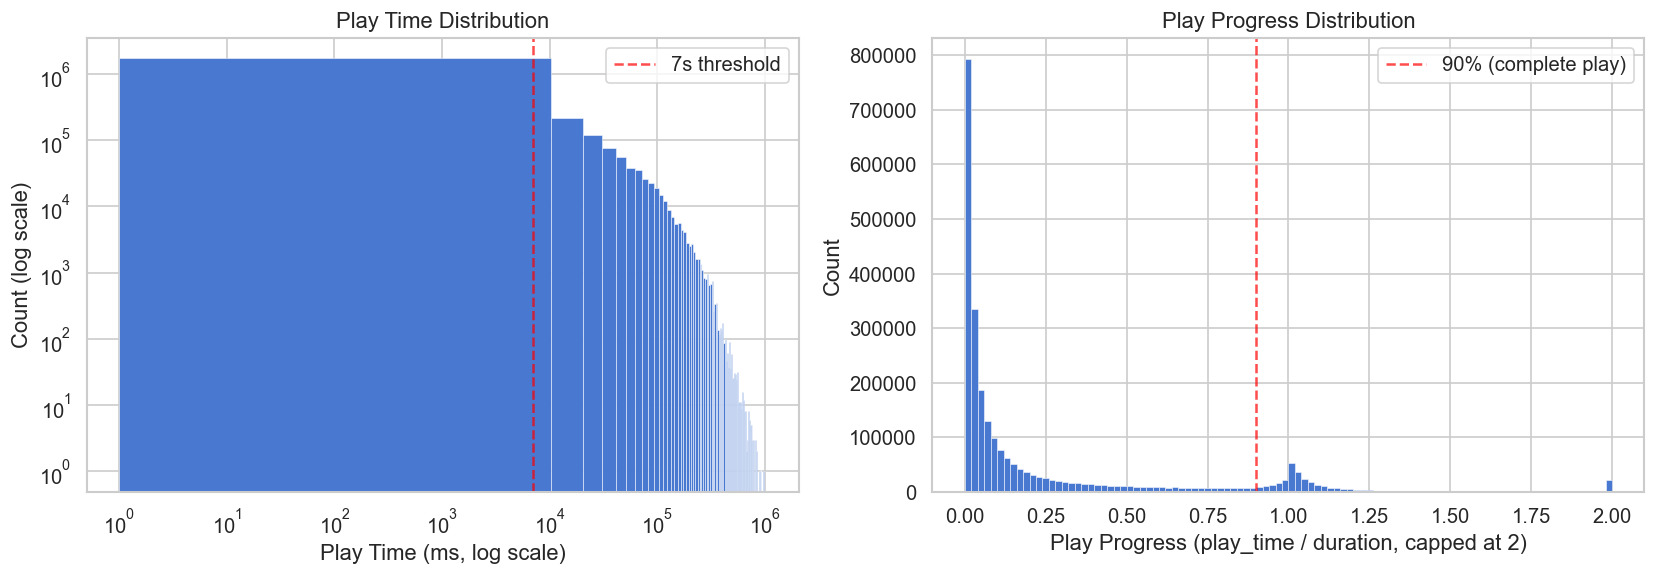


Play time stats (ms): median=2854, mean=15677
Play progress stats: median=0.055, mean=0.265


In [20]:
# play_time_ms as a continuous signal — distribution is heavily right-skewed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

play_ms = logs['play_time_ms']
axes[0].hist(play_ms[play_ms > 0], bins=100, edgecolor='white', linewidth=0.3)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Play Time (ms, log scale)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Play Time Distribution')
axes[0].axvline(7000, color='red', linestyle='--', alpha=0.7, label='7s threshold')
axes[0].legend()

# Play progress (continuous, 0 to ~1 for non-loops) — could be a rating
pp = valid_dur['play_ratio'].clip(upper=2)
axes[1].hist(pp, bins=100, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Play Progress (play_time / duration, capped at 2)')
axes[1].set_ylabel('Count')
axes[1].set_title('Play Progress Distribution')
axes[1].axvline(0.9, color='red', linestyle='--', alpha=0.7, label='90% (complete play)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nPlay time stats (ms): median={play_ms.median():.0f}, mean={play_ms.mean():.0f}")
print(f"Play progress stats: median={valid_dur['play_ratio'].median():.3f}, mean={valid_dur['play_ratio'].mean():.3f}")

### 4.2 Signal Correlations

How much agreement is there between the candidate signals? If two signals are highly correlated, the sparser one adds little value.

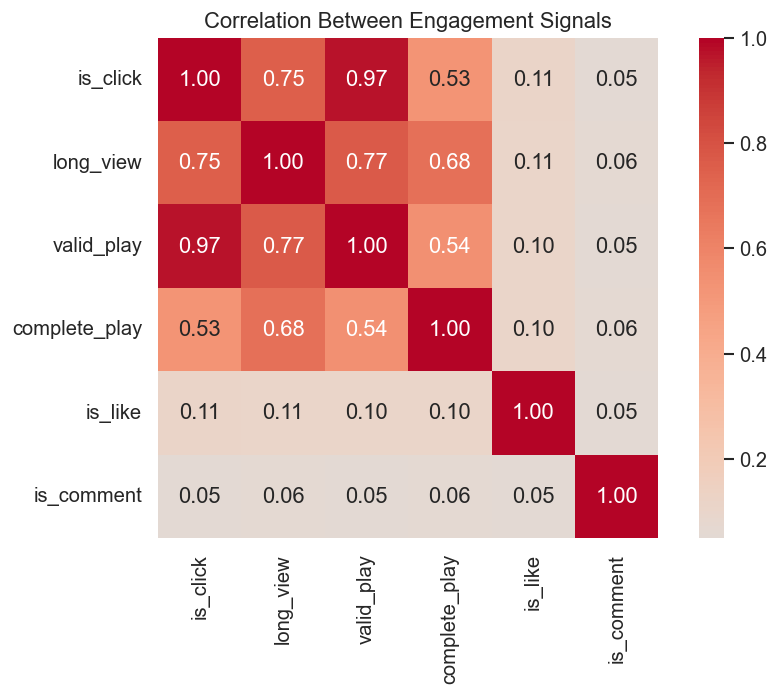

In [21]:
signal_cols = ['is_click', 'long_view', 'valid_play', 'complete_play', 'is_like', 'is_comment']
corr_signals = logs[signal_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_signals, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlation Between Engagement Signals')
plt.tight_layout()
plt.show()

### 4.3 Negative Feedback: Why Click Alone is Misleading

A click followed by immediate abandonment (< 3s on a long video) is negative feedback. We compare click-based vs. watch-based signals to quantify this gap.

Negative Engagement Signals (videos > 7s duration):
          hate_rate  short_abandon_rate  click_rate
is_rand                                            
Standard      0.050              27.682      46.427
Random        0.116              62.367      17.950


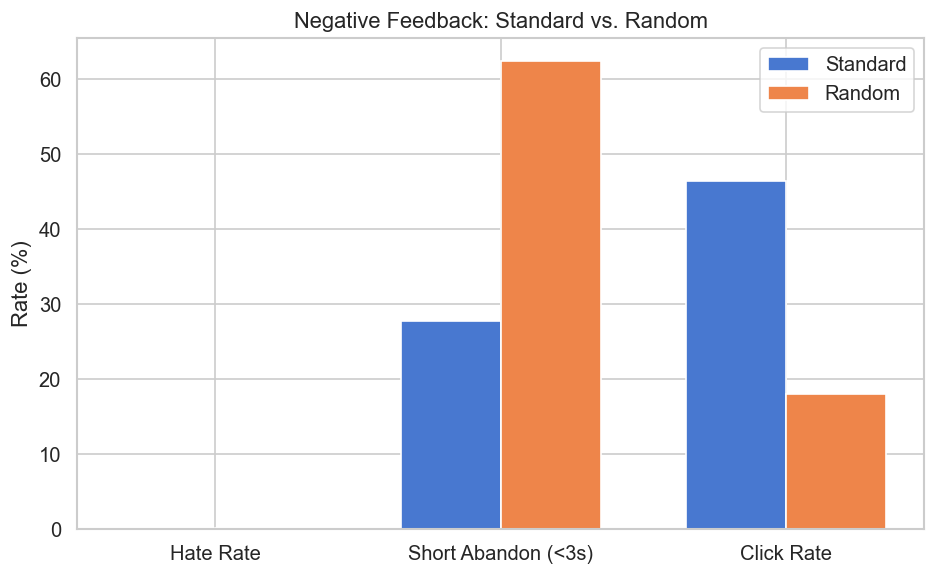

In [22]:
neg = logs[logs['duration_ms'] > 7000].copy()
neg['short_abandon'] = ((neg['play_time_ms'] > 0) & (neg['play_time_ms'] < 3000)).astype(int)

neg_by_rand = neg.groupby('is_rand').agg(
    hate_rate=('is_hate', 'mean'),
    short_abandon_rate=('short_abandon', 'mean'),
    click_rate=('is_click', 'mean')
)
neg_by_rand.index = neg_by_rand.index.map({0: 'Standard', 1: 'Random'})

print("Negative Engagement Signals (videos > 7s duration):")
print((neg_by_rand * 100).round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
neg_plot = (neg_by_rand * 100).T
x = np.arange(len(neg_plot))
width = 0.35
ax.bar(x - width/2, neg_plot['Standard'], width, label='Standard')
ax.bar(x + width/2, neg_plot['Random'], width, label='Random')
ax.set_ylabel('Rate (%)')
ax.set_title('Negative Feedback: Standard vs. Random')
ax.set_xticks(x)
ax.set_xticklabels(['Hate Rate', 'Short Abandon (<3s)', 'Click Rate'])
ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 5: Temporal Analysis and Train/Test Split

We plan to use a **temporal leave-one-out (LOO)** split: for each user, hold out their chronologically last interaction as the test item. This section validates that the data supports this approach.

### 5.1 Interaction Volume Over Time

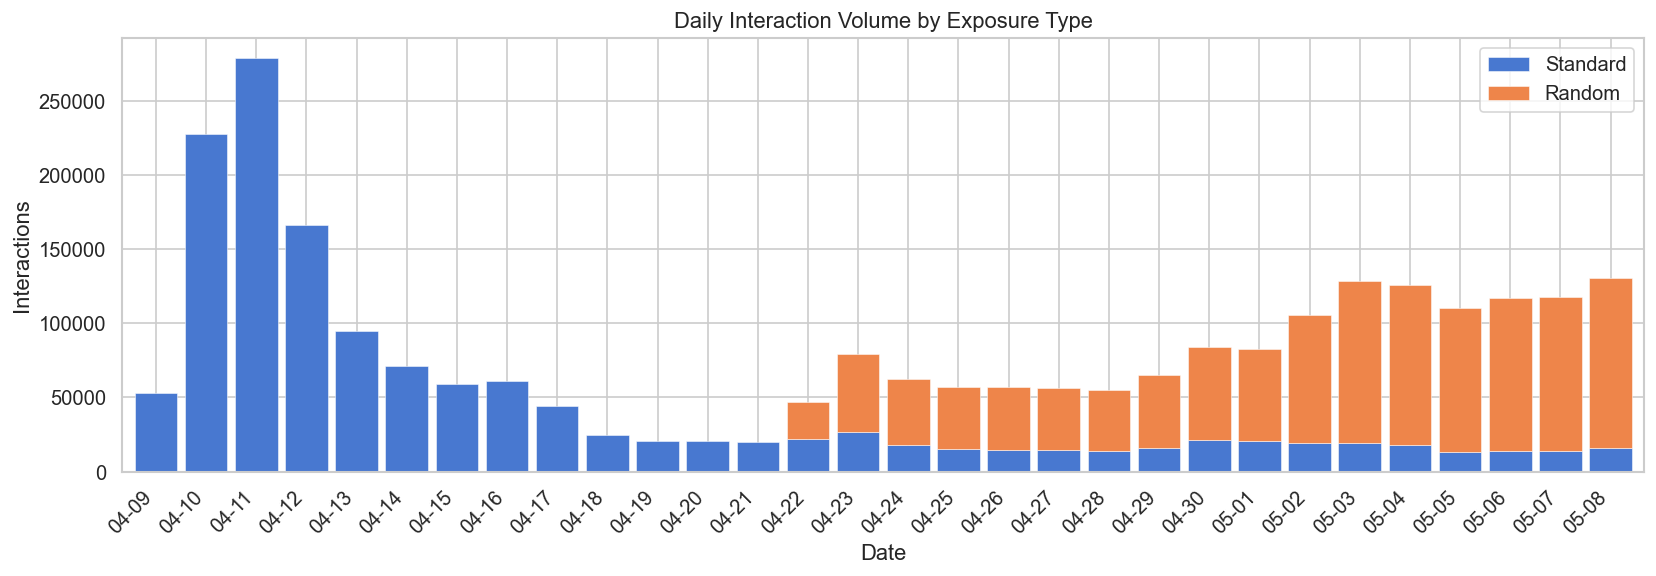

Date range: 2022-04-09 to 2022-05-08
Total days with data: 30


In [23]:
logs['date_dt'] = pd.to_datetime(logs['date'].astype(str), format='%Y%m%d')

daily_vol = logs.groupby(['date_dt', 'is_rand']).size().unstack(fill_value=0)
daily_vol.columns = daily_vol.columns.map({0: 'Standard', 1: 'Random'})

fig, ax = plt.subplots(figsize=(14, 5))
daily_vol.plot.bar(stacked=True, ax=ax, width=0.85, edgecolor='white', linewidth=0.3)
ax.set_ylabel('Interactions')
ax.set_title('Daily Interaction Volume by Exposure Type')
ax.set_xlabel('Date')
# Readable date labels
tick_labels = [d.strftime('%m-%d') for d in daily_vol.index]
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Date range: {logs['date_dt'].min().date()} to {logs['date_dt'].max().date()}")
print(f"Total days with data: {logs['date_dt'].nunique()}")

### 5.2 Leave-One-Out Split Feasibility

For temporal LOO to work, every user needs at least 2 interactions (1 for train, 1 for test). We also check the distribution of per-user interaction counts to understand how much training signal is available.

Users with only 1 interaction: 0
Users with >= 2 interactions:  27,285
Users with >= 5 interactions:  27,285
Users with >= 10 interactions: 27,285
Users with >= 20 interactions: 26,044


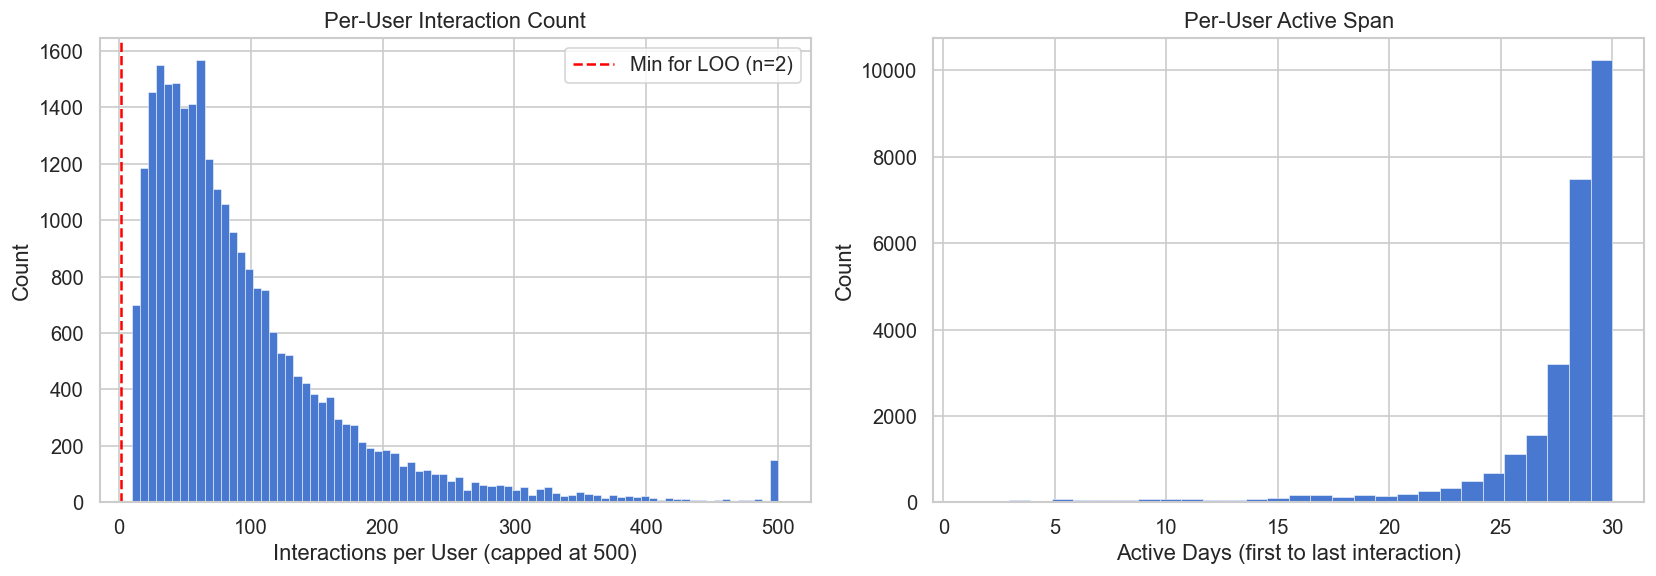

In [24]:
user_counts = logs.groupby('user_id').agg(
    n_interactions=('video_id', 'size'),
    n_unique_videos=('video_id', 'nunique'),
    first_date=('date_dt', 'min'),
    last_date=('date_dt', 'max')
)
user_counts['active_days'] = (user_counts['last_date'] - user_counts['first_date']).dt.days + 1

print(f"Users with only 1 interaction: {(user_counts['n_interactions'] == 1).sum():,}")
print(f"Users with >= 2 interactions:  {(user_counts['n_interactions'] >= 2).sum():,}")
print(f"Users with >= 5 interactions:  {(user_counts['n_interactions'] >= 5).sum():,}")
print(f"Users with >= 10 interactions: {(user_counts['n_interactions'] >= 10).sum():,}")
print(f"Users with >= 20 interactions: {(user_counts['n_interactions'] >= 20).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_counts['n_interactions'].clip(upper=500), bins=80, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Interactions per User (capped at 500)')
axes[0].set_ylabel('Count')
axes[0].set_title('Per-User Interaction Count')
axes[0].axvline(2, color='red', linestyle='--', label='Min for LOO (n=2)')
axes[0].legend()

axes[1].hist(user_counts['active_days'], bins=30, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Active Days (first to last interaction)')
axes[1].set_ylabel('Count')
axes[1].set_title('Per-User Active Span')

plt.tight_layout()
plt.show()

### 5.3 Train/Test Split Preview

Simulating the temporal LOO split: each user's last interaction becomes the test set. We check the resulting sizes and the date distribution of held-out items.

Train set: 2,595,383 interactions
Test set:  27,285 interactions (1 per user)
Test set date range: 2022-04-22 to 2022-05-08


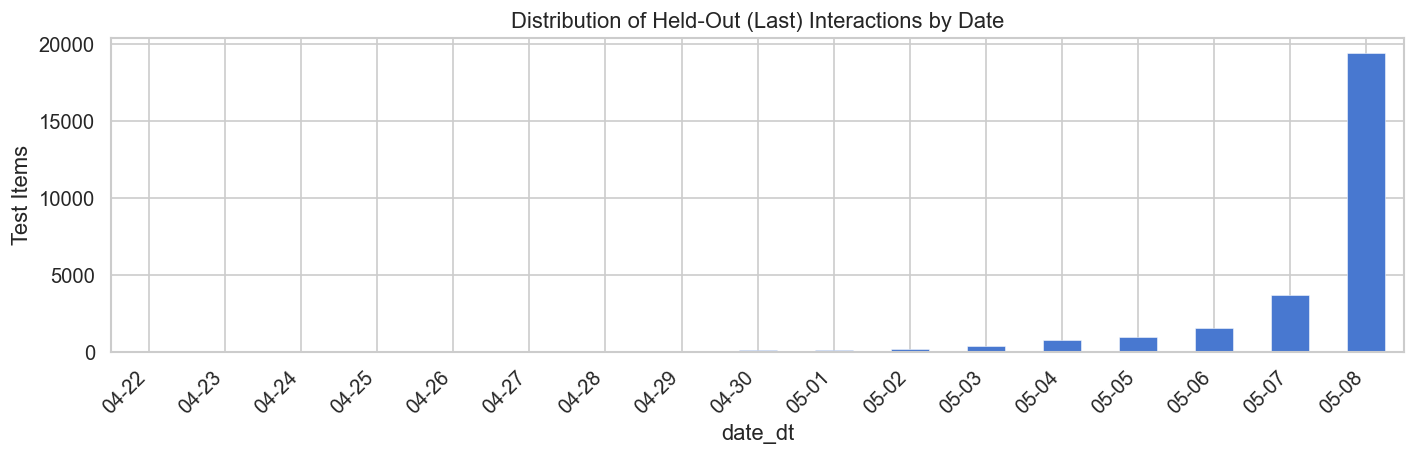


Test set by exposure type:
  Standard (is_rand=0): 6,198
  Random (is_rand=1):   21,087


In [25]:
# Sort by timestamp, then take last interaction per user
logs_sorted = logs.sort_values('time_ms')
test_idx = logs_sorted.groupby('user_id')['time_ms'].idxmax()
test_set = logs_sorted.loc[test_idx]
train_set = logs_sorted.drop(test_idx)

print(f"Train set: {len(train_set):,} interactions")
print(f"Test set:  {len(test_set):,} interactions (1 per user)")
print(f"Test set date range: {test_set['date_dt'].min().date()} to {test_set['date_dt'].max().date()}")

fig, ax = plt.subplots(figsize=(12, 4))
test_set['date_dt'].value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='white', linewidth=0.3)
ax.set_ylabel('Test Items')
ax.set_title('Distribution of Held-Out (Last) Interactions by Date')
tick_labels = [d.strftime('%m-%d') for d in test_set['date_dt'].value_counts().sort_index().index]
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Check how many test items come from random vs standard exposure
test_source = test_set['is_rand'].value_counts()
print(f"\nTest set by exposure type:")
print(f"  Standard (is_rand=0): {test_source.get(0, 0):,}")
print(f"  Random (is_rand=1):   {test_source.get(1, 0):,}")

---
## Phase 6: Modeling Readiness

Final checks to confirm SVD and the cold-start clustering fallback are viable.

### 6.1 Cold Start Prevalence

Users and items with very few interactions will produce unreliable SVD embeddings. We quantify how large the cold-start population is at various thresholds.

Cold-start users (interactions below threshold):
  <  1 interactions: 0 users (0.0%)
  <  2 interactions: 0 users (0.0%)
  <  5 interactions: 0 users (0.0%)
  < 10 interactions: 0 users (0.0%)
  < 20 interactions: 1,241 users (4.5%)
  < 50 interactions: 8,546 users (31.3%)

Cold-start items (interactions below threshold):
  <  1 interactions: 0 videos (0.0%)
  <  2 interactions: 0 videos (0.0%)
  <  5 interactions: 1 videos (0.0%)
  < 10 interactions: 3 videos (0.0%)
  < 20 interactions: 14 videos (0.2%)
  < 50 interactions: 67 videos (0.9%)


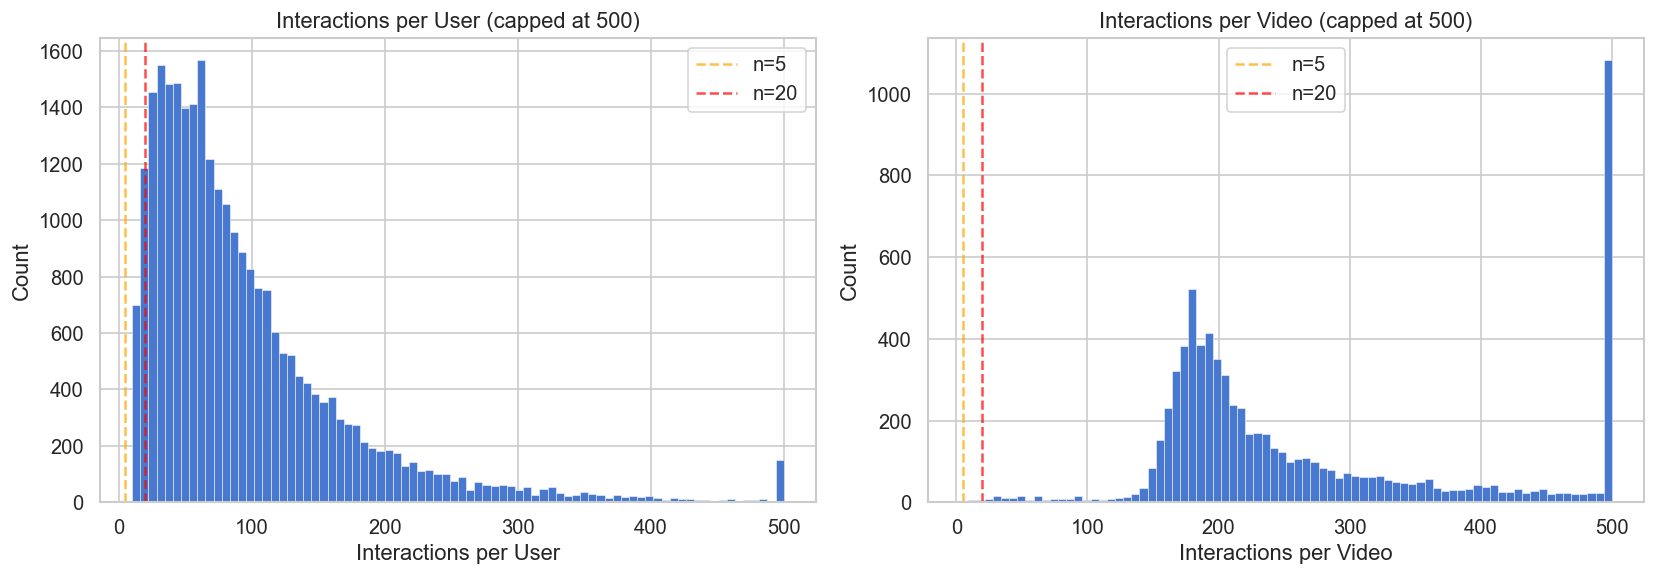

In [26]:
item_counts = logs.groupby('video_id').size().rename('n_interactions')

thresholds = [1, 2, 5, 10, 20, 50]

print("Cold-start users (interactions below threshold):")
for t in thresholds:
    n = (user_activity < t).sum()
    print(f"  < {t:2d} interactions: {n:,} users ({n/n_users*100:.1f}%)")

print(f"\nCold-start items (interactions below threshold):")
for t in thresholds:
    n = (item_counts < t).sum()
    print(f"  < {t:2d} interactions: {n:,} videos ({n/n_videos*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes,
    [user_activity, item_counts],
    ['Interactions per User', 'Interactions per Video']):
    ax.hist(data.clip(upper=500), bins=80, edgecolor='white', linewidth=0.3)
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.set_title(title + ' (capped at 500)')
    for t, color in [(5, 'orange'), (20, 'red')]:
        ax.axvline(t, color=color, linestyle='--', alpha=0.7, label=f'n={t}')
    ax.legend()

plt.tight_layout()
plt.show()

### 6.2 User Feature Clustering for Cold Start

Cold start is minimal in this dataset (all users have >= 10 interactions). However, user feature clustering is still useful for building a popularity-based baseline: recommend the most popular items within each user segment. We check whether clusters produce meaningfully different engagement profiles.

/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/p

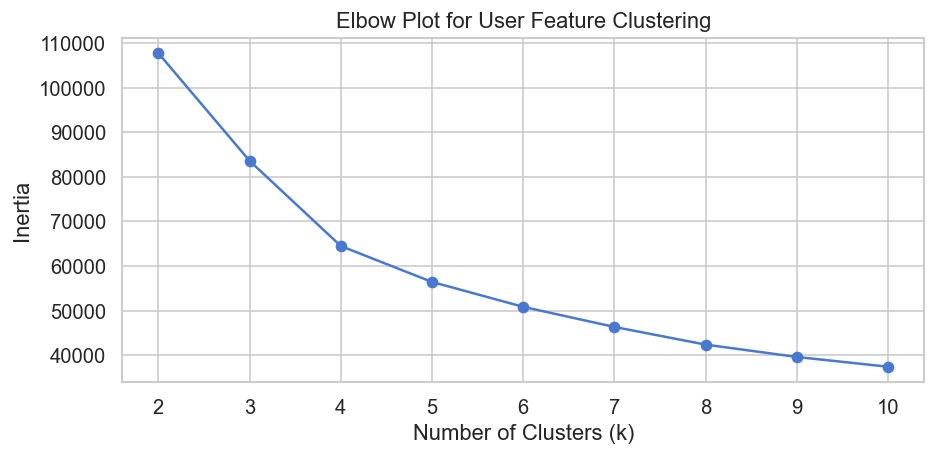

In [27]:
cluster_features = ['follow_user_num', 'fans_user_num', 'friend_user_num', 'register_days',
                     'is_live_streamer', 'is_video_author']

user_cluster_df = user_feat[['user_id'] + cluster_features].dropna().copy()

# Log-transform heavily skewed count features to prevent outlier-dominated clusters
log_cols = ['follow_user_num', 'fans_user_num', 'friend_user_num']
for col in log_cols:
    user_cluster_df[col] = np.log1p(user_cluster_df[col])

scaler = StandardScaler()
X = scaler.fit_transform(user_cluster_df[cluster_features])

inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, marker='o')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Plot for User Feature Clustering')
plt.tight_layout()
plt.show()

In [28]:
K = 5
km = KMeans(n_clusters=K, random_state=42, n_init=10)
user_cluster_df = user_cluster_df.copy()
user_cluster_df['cluster'] = km.fit_predict(X)

logs_with_cluster = logs.merge(user_cluster_df[['user_id', 'cluster']], on='user_id', how='inner')

cluster_eng = logs_with_cluster.groupby('cluster').agg(
    n_users=('user_id', 'nunique'),
    n_interactions=('user_id', 'size'),
    click_rate=('is_click', 'mean'),
    like_rate=('is_like', 'mean'),
    valid_play_rate=('valid_play', 'mean'),
)

print(f"User clusters (k={K}) — engagement profiles:")
display_df = cluster_eng.copy()
display_df[['click_rate', 'like_rate', 'valid_play_rate']] *= 100
print(display_df.round(2).to_string())

# Reverse log-transform on centroids for interpretability
centroids = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_),
                          columns=cluster_features)
for col in log_cols:
    centroids[col] = np.expm1(centroids[col])
print(f"\nCluster centroids (original scale):")
print(centroids.round(1).to_string())

/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/minhaozhang/Documents/Code/ADSP_31017/.venv/lib/p

User clusters (k=5) — engagement profiles:
         n_users  n_interactions  click_rate  like_rate  valid_play_rate
cluster                                                                 
0           4894          426299       32.35       0.84            31.70
1           5597          587248       34.00       2.04            32.36
2           5241          507473       35.26       1.21            34.31
3           5832          542793       31.10       0.92            30.03
4           5721          558855       32.91       0.99            31.99

Cluster centroids (original scale):
   follow_user_num  fans_user_num  friend_user_num  register_days  is_live_streamer  is_video_author
0             52.7            3.6              1.5          821.0            -123.0              0.0
1            464.3          305.3            166.5         1033.0            -124.0              1.0
2             40.1           12.9              3.5          652.0            -117.5              1.0
3    

### 6.3 Interaction Density After Filtering

SVD quality degrades with very sparse users/items. We check how matrix density improves when applying minimum interaction thresholds.

In [29]:
print(f"{'Min interactions':>18} {'Users':>8} {'Videos':>8} {'Pairs':>12} {'Density':>10}")
print("-" * 60)

for min_n in [0, 2, 5, 10, 20]:
    valid_users = user_activity[user_activity >= min_n].index
    valid_items = item_counts[item_counts >= min_n].index
    filtered = logs[(logs['user_id'].isin(valid_users)) & (logs['video_id'].isin(valid_items))]
    n_u = filtered['user_id'].nunique()
    n_v = filtered['video_id'].nunique()
    n_p = filtered.groupby(['user_id', 'video_id']).ngroups
    density = n_p / (n_u * n_v) * 100 if (n_u * n_v) > 0 else 0
    print(f"{min_n:>18} {n_u:>8,} {n_v:>8,} {n_p:>12,} {density:>9.4f}%")

  Min interactions    Users   Videos        Pairs    Density
------------------------------------------------------------
                 0   27,285    7,583    2,560,247    1.2374%
                 2   27,285    7,583    2,560,247    1.2374%
                 5   27,285    7,582    2,560,245    1.2376%
                10   27,285    7,580    2,560,232    1.2379%
                20   26,044    7,569    2,540,742    1.2889%


---
## Summary and Modeling Direction

In [30]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

print(f"\n1. SCALE")
print(f"   {n_interactions:,} total interactions across {n_users:,} users and {n_videos:,} videos")
print(f"   Interaction matrix sparsity: {sparsity*100:.4f}%")

print(f"\n2. USER ACTIVITY INEQUALITY")
print(f"   Top 10% of users generate {top10_pct:.1%} of interactions")

print(f"\n3. ALGORITHMIC AMPLIFICATION (Standard vs Random rates):")
for col in ['is_click', 'valid_play', 'is_like']:
    std_rate = eng_by_rand.loc['Standard', col]
    rnd_rate = eng_by_rand.loc['Random', col]
    label = col.replace('is_', '').replace('_', ' ').title()
    if rnd_rate > 0:
        print(f"   {label}: {std_rate*100:.2f}% vs {rnd_rate*100:.2f}% ({std_rate/rnd_rate:.1f}x amplification)")

print(f"\n4. DATA QUALITY")
print(f"   Duplicate entries: {dup_count:,}")
print(f"   Zero/negative durations: {zero_duration:,}")

print(f"\n5. ENGAGEMENT METRIC RECOMMENDATION")
print(f"   is_click is too noisy — 62% of random-exposure plays on >7s videos are abandoned <3s")
print(f"   is_like/is_comment are too sparse (0.48% / 0.035% under random exposure)")
print(f"   Recommended: 'valid_play' (play >= 7s or long_view) — 32% positive rate, semantically meaningful")
print(f"   Alternative: play_progress (continuous) if SVD supports real-valued ratings")

print(f"\n6. TEMPORAL LOO SPLIT")
n_single = (user_activity == 1).sum()
print(f"   Users with only 1 interaction: {n_single:,}")
print(f"   LOO is feasible for all {n_users:,} users")
print(f"   Test set: 77% random exposure — provides unbiased evaluation")

print(f"\n7. COLD START")
cold_10 = (user_activity < 10).sum()
cold_20 = (user_activity < 20).sum()
print(f"   Users with < 10 interactions: {cold_10:,} — cold start is not a problem in this dataset")
print(f"   Users with < 20 interactions: {cold_20:,} ({cold_20/n_users*100:.1f}%)")
print(f"   All videos have >= 2 interactions; only 14 videos have < 20")
print(f"   User feature clustering still useful as a popularity-based baseline")

KEY FINDINGS

1. SCALE
   2,622,668 total interactions across 27,285 users and 7,583 videos
   Interaction matrix sparsity: 98.7626%

2. USER ACTIVITY INEQUALITY
   Top 10% of users generate 30.0% of interactions

3. ALGORITHMIC AMPLIFICATION (Standard vs Random rates):
   Click: 45.97% vs 17.62% (2.6x amplification)
   Valid Play: 44.34% vs 17.21% (2.6x amplification)
   Like: 1.85% vs 0.48% (3.9x amplification)

4. DATA QUALITY
   Duplicate entries: 23,483
   Zero/negative durations: 65,794

5. ENGAGEMENT METRIC RECOMMENDATION
   is_click is too noisy — 62% of random-exposure plays on >7s videos are abandoned <3s
   is_like/is_comment are too sparse (0.48% / 0.035% under random exposure)
   Recommended: 'valid_play' (play >= 7s or long_view) — 32% positive rate, semantically meaningful
   Alternative: play_progress (continuous) if SVD supports real-valued ratings

6. TEMPORAL LOO SPLIT
   Users with only 1 interaction: 0
   LOO is feasible for all 27,285 users
   Test set: 77% random